# Mimir usage -- tenants / series budget / capacity planning

Who is spending the series and query budget, and how it is trending: active series
vs limits per tenant, ingest and discards, query load, ruler quotas, cardinality
drivers, block counts. Health of the system itself: [mimir-health.ipynb](mimir-health.ipynb);
when Mimir can't answer at all: [mimir-nolgtm.ipynb](mimir-nolgtm.ipynb).

Design: [tiles#644](https://github.com/symmatree/tiles/issues/644),
[docs/mimir.md](../docs/mimir.md).

Run from `notebooks/`: `jupyter nbconvert --to notebook --execute --inplace mimir-usage.ipynb`

In [1]:
mimir_url = "http://mimir-gateway.mimir.svc"
tenant = "tiles"       # X-Scope-OrgID; also the tenant whose cardinality is broken down
lookback_days = 7
range_step_s = 3600
capture_file = ""      # replay a prior raw capture JSON instead of querying live
output_dir = ""        # if set: write raw capture + agent stats there
debug = False

In [2]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path
import nb_capture as nbc

plt.rcParams.update(nbc.MPL_STYLE)
NOTEBOOK = 'mimir-usage'
cap = nbc.Capture(replay_file=capture_file, mimir_url=mimir_url, tenant=tenant,
                  lookback_days=lookback_days, range_step_s=range_step_s)
tenant = cap.meta['tenant']
lookback_days, step = cap.meta['lookback_days'], cap.meta['range_step_s']
LOOKBACK_H = lookback_days * 24
mm = nbc.Mimir(cap, cap.meta['mimir_url'], tenant)

TENANT_COLOR = {}  # fixed color per tenant across all plots, assigned on first sight
def tenant_color(user):
    if user not in TENANT_COLOR:
        TENANT_COLOR[user] = f"C{len(TENANT_COLOR)}"
    return TENANT_COLOR[user]

print(f"mimir: {cap.meta['mimir_url']}  tenant: {tenant}  window: {lookback_days}d  "
      f"{'REPLAY of ' + cap.run_at if cap.replay else 'live'}")

mimir: http://mimir-gateway.mimir.svc  tenant: tiles  window: 7d  live


In [3]:
# --- ASSUMPTIONS (light): the stack is assumed working -- mimir-nolgtm.ipynb is
# the tool for when it isn't. Just prove the instrument is alive and fresh before
# reading capacity numbers off it.
binfo = mm.get('buildinfo', '/prometheus/api/v1/status/buildinfo')
mimir_version = binfo.get('json', {}).get('data', {}).get('version', 'unknown')
age_s = cap.now - nbc.val(mm.q('freshness', 'max(timestamp(cortex_ingester_memory_series))'))
print(f"mimir {mimir_version}: reachable; newest self-metric {age_s:.0f}s old")
if not (age_s < 600):
    raise RuntimeError(f"unassessable: cortex self-monitoring stale or absent ({age_s:.0f}s)")

mimir 3.0.1: reachable; newest self-metric 29s old


In [4]:
# --- CAPTURE: fetch the complete observation up front, before any analysis ---
series_limit = nbc.val(mm.q('series_limit', 'max(cortex_limits_defaults{limit_name="max_global_series_per_user"})'))
active_by_tenant = nbc.by(mm.q('active_series_by_tenant', 'sum by (user) (cortex_ingester_active_series)'), 'user')
series_in_memory = nbc.val(mm.q('series_in_memory', 'sum(cortex_ingester_memory_series)'))
ruler_limits = nbc.by(mm.q('ruler_limits', 'cortex_limits_defaults{limit_name=~"ruler_max_.*"}'), 'limit_name')
rule_groups = nbc.by(mm.q('rule_groups_by_tenant', 'count by (user) (cortex_prometheus_rule_group_rules)'), 'user')
rules = nbc.by(mm.q('rules_by_tenant', 'sum by (user) (cortex_prometheus_rule_group_rules)'), 'user')
blocks = nbc.by(mm.q('blocks_by_tenant', 'max by (user) (cortex_bucket_blocks_count)'), 'user')

f_active = nbc.frame(mm.qr('active_series_trend', 'sum by (user) (cortex_ingester_active_series)', LOOKBACK_H, step), 'user')
f_ingest = nbc.frame(mm.qr('ingest_rate', 'sum(rate(cortex_distributor_received_samples_total[5m]))', LOOKBACK_H, step), None)
f_discard = nbc.frame(mm.qr('discarded_by_reason', 'sum by (reason) (rate(cortex_discarded_samples_total[5m]))', LOOKBACK_H, step), 'reason')
f_qrate = nbc.frame(mm.qr('query_rate_by_route',
    'sum by (route) (rate(cortex_request_duration_seconds_count{route=~"prometheus_api_v1_.*"}[5m]))', LOOKBACK_H, step), 'route')
f_qp99 = nbc.frame(mm.qr('query_p99',
    'histogram_quantile(0.99, sum by (le) (rate(cortex_request_duration_seconds_bucket{route=~"prometheus_api_v1_query.*"}[5m])))', LOOKBACK_H, step), None)

card_labels = mm.get('cardinality_label_names', '/prometheus/api/v1/cardinality/label_names', limit=15)['json']
card_metrics = mm.get('cardinality_metric_names', '/prometheus/api/v1/cardinality/label_values',
                      **{'label_names[]': '__name__', 'limit': 15})['json']
print(f"captured {len(cap.data['calls'])} calls, ~{len(json.dumps(cap.data)) / 1024:.0f} KB raw")

captured 16 calls, ~41 KB raw


per-tenant limit (max_global_series_per_user): 500,000
in-memory series across ingesters: 104,872
       active_series  pct_of_limit  window_delta
tiles       91,355.0          18.3       6,265.0


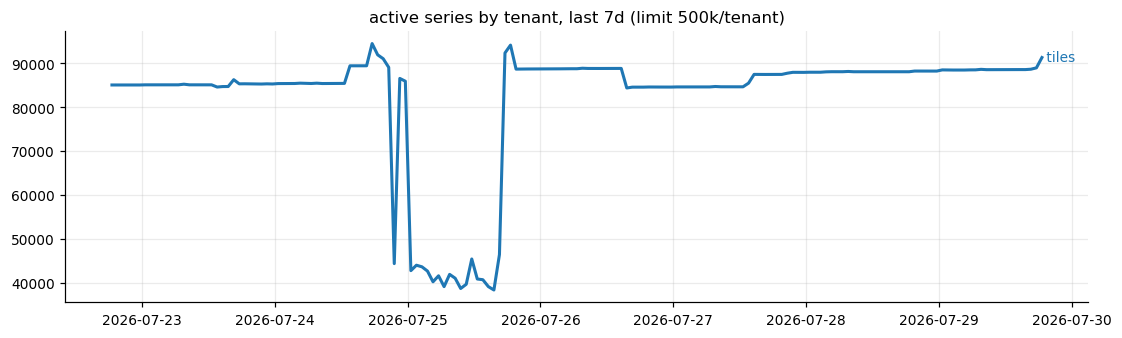

In [5]:
# --- SERIES BUDGET: active series per tenant vs max_global_series_per_user ---
budget = pd.DataFrame({'active_series': pd.Series(active_by_tenant)})
budget['pct_of_limit'] = 100 * budget['active_series'] / series_limit
delta = (f_active.iloc[-1] - f_active.iloc[0]).rename('window_delta')
budget = budget.join(delta)
print(f"per-tenant limit (max_global_series_per_user): {series_limit:,.0f}")
print(f"in-memory series across ingesters: {series_in_memory:,.0f}")
print(budget.sort_values('active_series', ascending=False)
      .to_string(float_format=lambda v: f'{v:,.1f}'))

fig, ax = plt.subplots(figsize=(12, 3.2))
for user in f_active.columns:
    ax.plot(f_active.index, f_active[user], color=tenant_color(user), lw=2)
    ax.annotate(f" {user}", (f_active.index[-1], f_active[user].iloc[-1]),
                color=tenant_color(user), va='center')
ax.set_title(f'active series by tenant, last {lookback_days}d '
             f'(limit {series_limit / 1e3:.0f}k/tenant)')
nbc.show(fig)

ingest: 2,904 samples/s now; mean 2,752, max 2,904 over 7d
discards by reason (mean/s): {'new-value-for-timestamp': 0.511, 'rate_limited': 0.053, 'sample-out-of-order': 2.112}


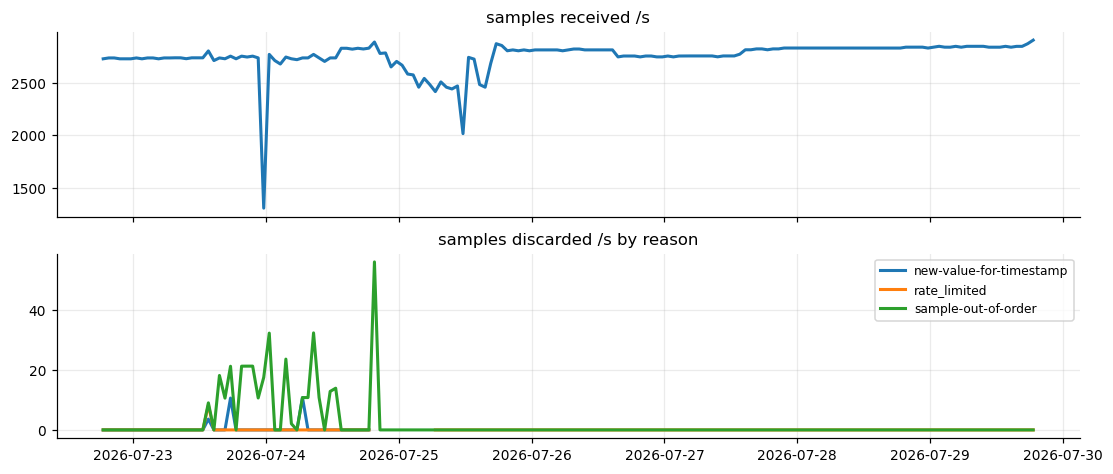

In [6]:
# --- INGEST: samples/s received; discarded/rejected by reason ---
ing = f_ingest['value']
print(f"ingest: {ing.iloc[-1]:,.0f} samples/s now; "
      f"mean {ing.mean():,.0f}, max {ing.max():,.0f} over {lookback_days}d")
f_discard_nz = f_discard.loc[:, f_discard.max() > 0] if not f_discard.empty else f_discard
discard_mean = {c: round(float(f_discard_nz[c].mean()), 3) for c in f_discard_nz.columns}
print(f"discards by reason (mean/s): {discard_mean or 'none in window'}")

fig, axes = plt.subplots(2, 1, figsize=(12, 4.8), sharex=True)
axes[0].plot(ing.index, ing, color='C0', lw=2)
axes[0].set_title('samples received /s')
if f_discard_nz.empty:
    axes[1].text(0.5, 0.5, 'no discarded samples in window', ha='center', va='center',
                 transform=axes[1].transAxes, color='0.4')
    axes[1].grid(False)
else:
    for c in f_discard_nz.columns:
        axes[1].plot(f_discard_nz.index, f_discard_nz[c], lw=2, label=c)
    axes[1].legend(fontsize=8)
axes[1].set_title('samples discarded /s by reason')
nbc.show(fig)

mean requests/s by route (top 5):
prometheus_api_v1_query                      0.361
prometheus_api_v1_query_range                0.091
prometheus_api_v1_label_name_values          0.001
prometheus_api_v1_cardinality_label_values   0.000
prometheus_api_v1_cardinality_label_names    0.000
query p99 latency: max 0.45s over window


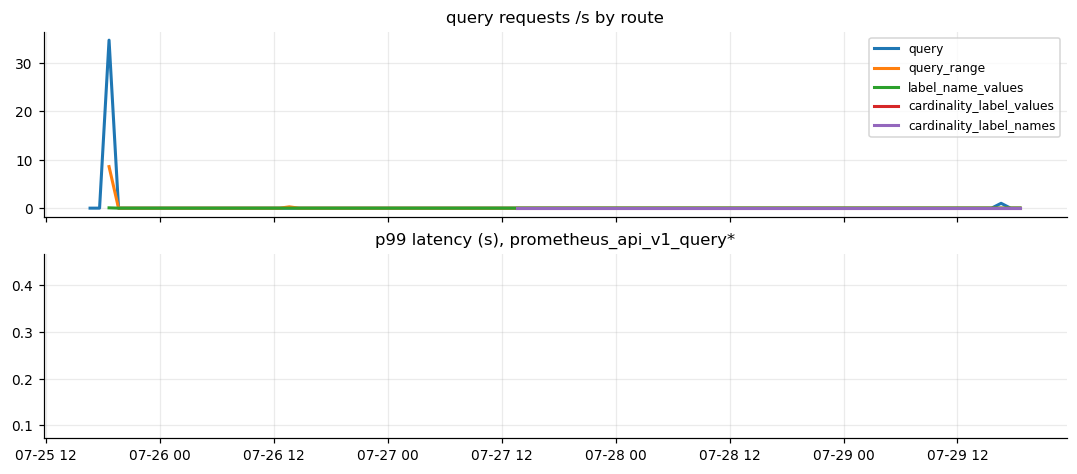

In [7]:
# --- QUERY LOAD: request rate by route; p99 latency for query routes ---
qrate_top = f_qrate.loc[:, f_qrate.mean().sort_values(ascending=False).head(5).index]
print("mean requests/s by route (top 5):")
print(qrate_top.mean().to_string(float_format=lambda v: f'{v:.3f}'))

fig, axes = plt.subplots(2, 1, figsize=(12, 4.8), sharex=True)
for c in qrate_top.columns:
    axes[0].plot(qrate_top.index, qrate_top[c], lw=2,
                 label=c.replace('prometheus_api_v1_', ''))
axes[0].legend(fontsize=8)
axes[0].set_title('query requests /s by route')
p99 = f_qp99['value'] if not f_qp99.empty else pd.Series(dtype=float)
if p99.notna().any():
    axes[1].plot(p99.index, p99, color='C0', lw=2)
    print(f"query p99 latency: max {p99.max():.2f}s over window")
else:
    axes[1].text(0.5, 0.5, 'no query traffic in window', ha='center', va='center',
                 transform=axes[1].transAxes, color='0.4')
    axes[1].grid(False)
axes[1].set_title('p99 latency (s), prometheus_api_v1_query*')
nbc.show(fig)

In [8]:
# --- RULER QUOTAS & BLOCKS per tenant ---
group_limit = ruler_limits.get('ruler_max_rule_groups_per_tenant', np.nan)
for user in sorted(rules):
    print(f"  {user}: {rule_groups.get(user, 0):.0f} groups "
          f"({100 * rule_groups.get(user, 0) / group_limit:.0f}% of {group_limit:.0f}), "
          f"{rules[user]:.0f} rules "
          f"(limit {ruler_limits.get('ruler_max_rules_per_rule_group', np.nan):.0f}/group)")
print(f"blocks by tenant: { {u: int(n) for u, n in sorted(blocks.items())} }")

  tiles: 79 groups (40% of 200), 447 rules (limit 100/group)
blocks by tenant: {'tiles': 181}


tenant 'tiles' series total (cardinality API): 104,872


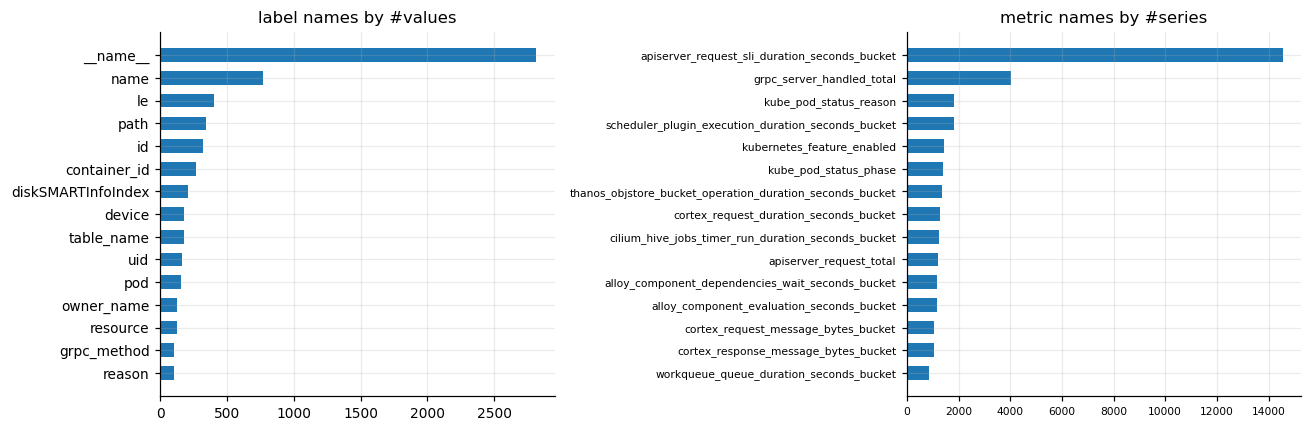

In [9]:
# --- CARDINALITY DRIVERS: what is spending the series budget (tenant view) ---
top_labels = pd.Series({c['label_name']: c['label_values_count']
                        for c in card_labels['cardinality']})
top_metrics = pd.Series({c['label_value']: c['series_count']
                         for c in card_metrics['labels'][0]['cardinality']})
card_total = card_metrics['series_count_total']
print(f"tenant '{tenant}' series total (cardinality API): {card_total:,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(top_labels.index[::-1], top_labels.values[::-1], color='C0', height=0.6)
axes[0].set_title('label names by #values')
axes[1].barh(top_metrics.index[::-1], top_metrics.values[::-1], color='C0', height=0.6)
axes[1].set_title('metric names by #series')
axes[1].tick_params(labelsize=7)
fig.tight_layout()
nbc.show(fig)

In [10]:
# --- SUMMARY: findings vs explicit thresholds ---
findings = []
for user, pct in (100 * budget['pct_of_limit'] / 100).items():
    if budget.loc[user, 'pct_of_limit'] > 80:
        findings.append(f"tenant {user} at {budget.loc[user, 'pct_of_limit']:.0f}% of series limit (>80%)")
limit_discards = {c: v for c, v in discard_mean.items()
                  if 'limit' in c or 'rate' in c or 'too_many' in c}
if limit_discards:
    findings.append(f"limit-shaped discards present: {limit_discards}")
for user in rules:
    if group_limit and 100 * rule_groups.get(user, 0) / group_limit > 80:
        findings.append(f"tenant {user} at {100 * rule_groups[user] / group_limit:.0f}% of rule-group limit")

tenant_pct = budget['pct_of_limit'].get(tenant, np.nan)
print("=" * 60)
print("MIMIR USAGE SUMMARY")
print("=" * 60)
print(f"run:      {cap.run_at}  ({cap.mode})")
print(f"mimir:    {mimir_version}, window {lookback_days}d")
print()
if findings:
    print("Findings:")
    for f in findings:
        print(f"  ! {f}")
else:
    print("Findings: none -- ample headroom everywhere")
print()
print(f"  Series:   { {u: f'{v:,.0f}' for u, v in sorted(active_by_tenant.items())} } "
      f"of {series_limit / 1e3:.0f}k/tenant; {tenant} at {tenant_pct:.1f}%, "
      f"{lookback_days}d delta {delta.get(tenant, np.nan):+,.0f}")
print(f"  Ingest:   {ing.mean():,.0f} samples/s mean; discards {discard_mean or 'none'}")
print(f"  Queries:  {qrate_top.mean().sum():.3f} req/s mean across routes")
print(f"  Ruler:    { {u: f'{rule_groups.get(u, 0):.0f} groups' for u in sorted(rules)} } "
      f"(limit {group_limit:.0f})")
print(f"  Blocks:   { {u: int(n) for u, n in sorted(blocks.items())} }")

MIMIR USAGE SUMMARY
run:      2026-07-29T18:36:16.830332+00:00  (live)
mimir:    3.0.1, window 7d

Findings:
  ! limit-shaped discards present: {'rate_limited': 0.053}

  Series:   {'tiles': '91,355'} of 500k/tenant; tiles at 18.3%, 7d delta +6,265
  Ingest:   2,752 samples/s mean; discards {'new-value-for-timestamp': 0.511, 'rate_limited': 0.053, 'sample-out-of-order': 2.112}
  Queries:  0.453 req/s mean across routes
  Ruler:    {'tiles': '79 groups'} (limit 200)
  Blocks:   {'tiles': 181}


In [11]:
# AGENT-READABLE STATS -- consolidated JSON for programmatic consumption.
def _n(v):
    return None if v is None or (isinstance(v, float) and not np.isfinite(v)) else round(float(v), 4)

agent_stats = {
    'notebook': f'{NOTEBOOK}.ipynb',
    'run_at': cap.run_at,
    'mode': cap.mode,
    'mimir_version': mimir_version,
    'lookback_days': lookback_days,
    'findings': findings,
    'series': {
        'limit_per_tenant': _n(series_limit),
        'active_by_tenant': {u: _n(v) for u, v in active_by_tenant.items()},
        'pct_of_limit_by_tenant': {u: _n(v) for u, v in budget['pct_of_limit'].items()},
        'window_delta_by_tenant': {u: _n(v) for u, v in delta.items()},
        'in_memory_total': _n(series_in_memory),
    },
    'ingest': {
        'samples_per_s': {'now': _n(ing.iloc[-1]), 'mean': _n(ing.mean()), 'max': _n(ing.max())},
        'discarded_per_s_mean_by_reason': discard_mean,
    },
    'queries': {
        'rate_per_s_mean_by_route': {c: _n(qrate_top[c].mean()) for c in qrate_top.columns},
        'p99_s_max': _n(p99.max()) if p99.notna().any() else None,
    },
    'ruler': {
        'groups_by_tenant': {u: _n(v) for u, v in rule_groups.items()},
        'rules_by_tenant': {u: _n(v) for u, v in rules.items()},
        'limits': {k: _n(v) for k, v in ruler_limits.items()},
    },
    'storage': {'blocks_by_tenant': {u: int(v) for u, v in blocks.items()}},
    'cardinality': {
        'tenant_series_total': int(card_total),
        'top_label_names_by_values': {k: int(v) for k, v in top_labels.items()},
        'top_metrics_by_series': {k: int(v) for k, v in top_metrics.items()},
    },
}
print(json.dumps(agent_stats, indent=1))

if output_dir:
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)
    cap.save(out / f'{NOTEBOOK}.capture.json')
    (out / f'{NOTEBOOK}.stats.json').write_text(json.dumps(agent_stats, indent=2))
    print(f"wrote {out / f'{NOTEBOOK}.capture.json'} and {out / f'{NOTEBOOK}.stats.json'}")

{
 "notebook": "mimir-usage.ipynb",
 "run_at": "2026-07-29T18:36:16.830332+00:00",
 "mode": "live",
 "mimir_version": "3.0.1",
 "lookback_days": 7,
 "findings": [
  "limit-shaped discards present: {'rate_limited': 0.053}"
 ],
 "series": {
  "limit_per_tenant": 500000.0,
  "active_by_tenant": {
   "tiles": 91355.0
  },
  "pct_of_limit_by_tenant": {
   "tiles": 18.271
  },
  "window_delta_by_tenant": {
   "tiles": 6265.0
  },
  "in_memory_total": 104872.0
 },
 "ingest": {
  "samples_per_s": {
   "now": 2903.7667,
   "mean": 2751.5492,
   "max": 2903.7667
  },
  "discarded_per_s_mean_by_reason": {
   "new-value-for-timestamp": 0.511,
   "rate_limited": 0.053,
   "sample-out-of-order": 2.112
  }
 },
 "queries": {
  "rate_per_s_mean_by_route": {
   "prometheus_api_v1_query": 0.3607,
   "prometheus_api_v1_query_range": 0.0913,
   "prometheus_api_v1_label_name_values": 0.0006,
   "prometheus_api_v1_cardinality_label_values": 0.0,
   "prometheus_api_v1_cardinality_label_names": 0.0
  },
  "p99